 Выполнил: Глушко Игорь М80-312Б-23

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.sparse as sp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.base import clone

In [2]:

df = pd.read_csv("datasets/train_c.csv")
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0


In [3]:
test = pd.read_csv("datasets/test_c.csv")

## EDA

In [4]:
print("\nСтруктура датасета:")
print(df.info())



Структура датасета:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToInco

In [5]:
print("\nПроверка на пропуски в данных:")
df.isnull().sum()


Проверка на пропуски в данных:


ApplicationDate                530
Age                            530
AnnualIncome                   530
CreditScore                   1031
LoanAmount                    1031
LoanDuration                   530
MaritalStatus                  530
NumberOfDependents             530
HomeOwnershipStatus            530
MonthlyDebtPayments           1031
CreditCardUtilizationRate      530
NumberOfOpenCreditLines        530
NumberOfCreditInquiries        530
DebtToIncomeRatio              530
BankruptcyHistory             1031
LoanPurpose                   1031
PreviousLoanDefaults           530
PaymentHistory                 530
LengthOfCreditHistory          530
SavingsAccountBalance          530
CheckingAccountBalance        1031
TotalAssets                   1031
TotalLiabilities               530
MonthlyIncome                  530
UtilityBillsPaymentHistory     530
JobTenure                      530
EmploymentStatus               530
EducationLevel                 530
Experience          

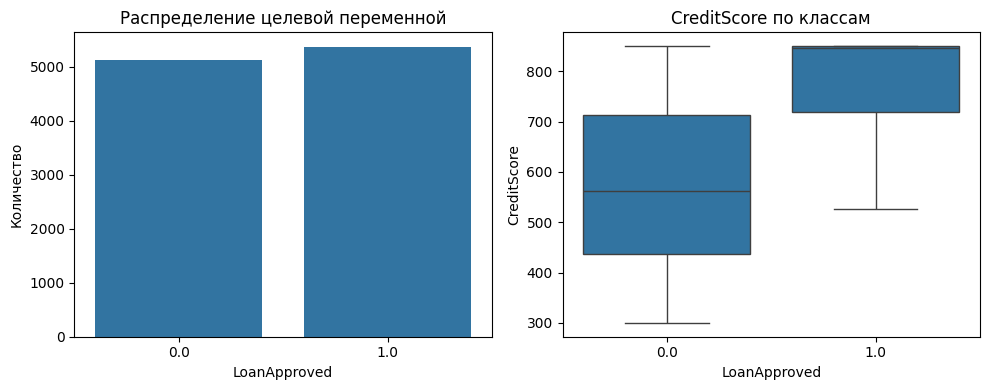

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x="LoanApproved", data=df, ax=axes[0])
axes[0].set_title("Распределение целевой переменной")
axes[0].set_xlabel("LoanApproved")
axes[0].set_ylabel("Количество")

sns.boxplot(x="LoanApproved", y="CreditScore", data=df, showfliers=False, ax=axes[1])
axes[1].set_title("CreditScore по классам")
axes[1].set_xlabel("LoanApproved")
axes[1].set_ylabel("CreditScore")

plt.tight_layout()
plt.show()

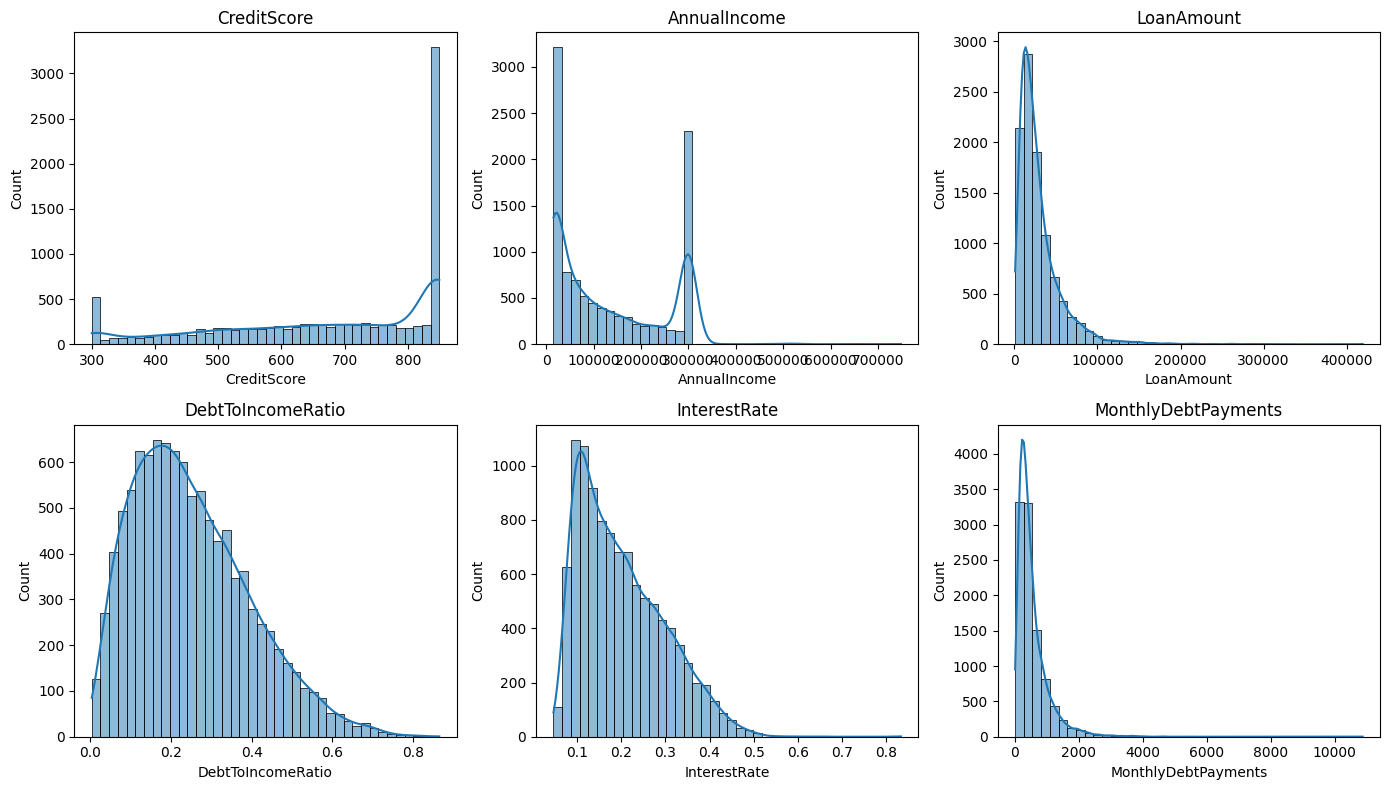

In [7]:
num_cols = [
    "CreditScore",
    "AnnualIncome",
    "LoanAmount",
    "DebtToIncomeRatio",
    "InterestRate",
    "MonthlyDebtPayments",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

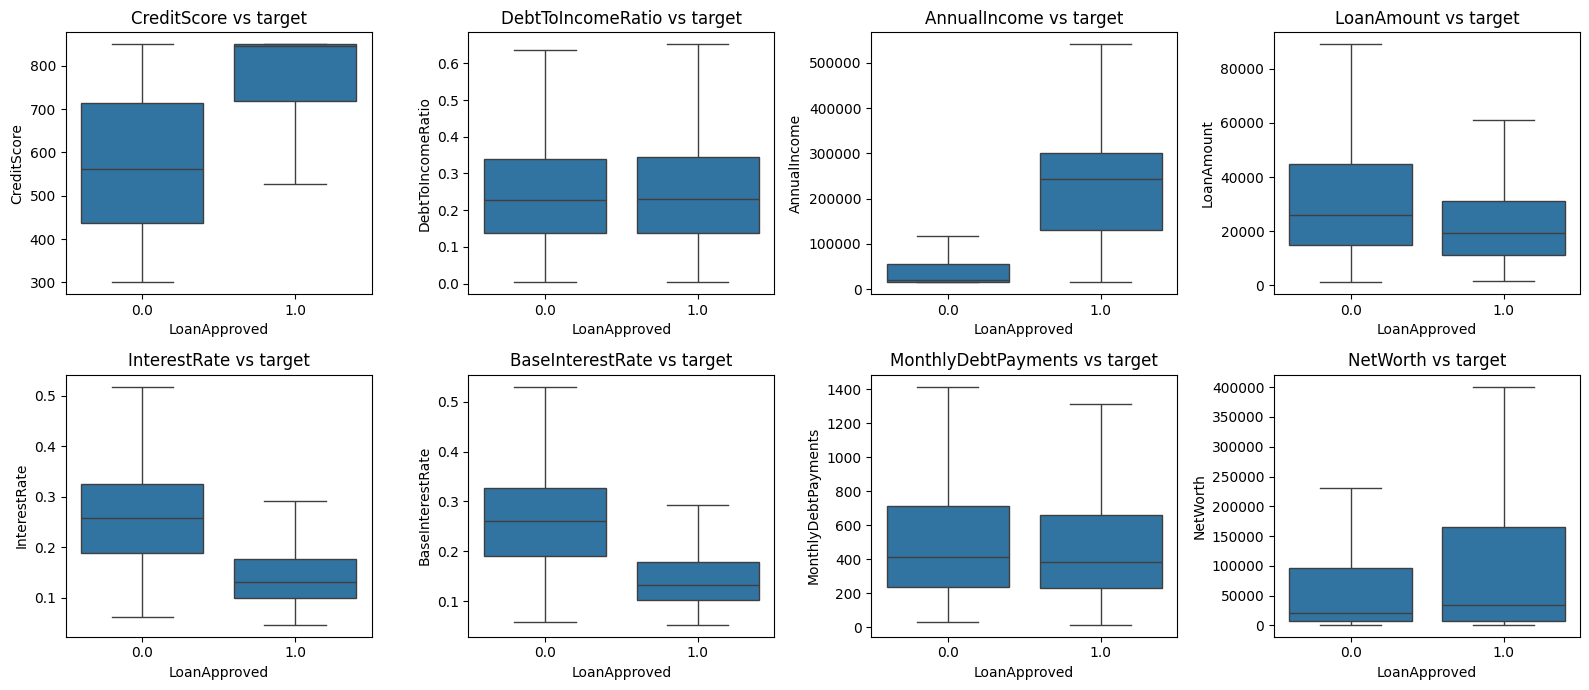

In [8]:
num_cols = [
    "CreditScore",
    "DebtToIncomeRatio",
    "AnnualIncome",
    "LoanAmount",
    "InterestRate",
    "BaseInterestRate",
    "MonthlyDebtPayments",
    "NetWorth",
]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(x="LoanApproved", y=col, data=df, showfliers=False, ax=ax)
    ax.set_title(f"{col} vs target")
plt.tight_layout()
plt.show()

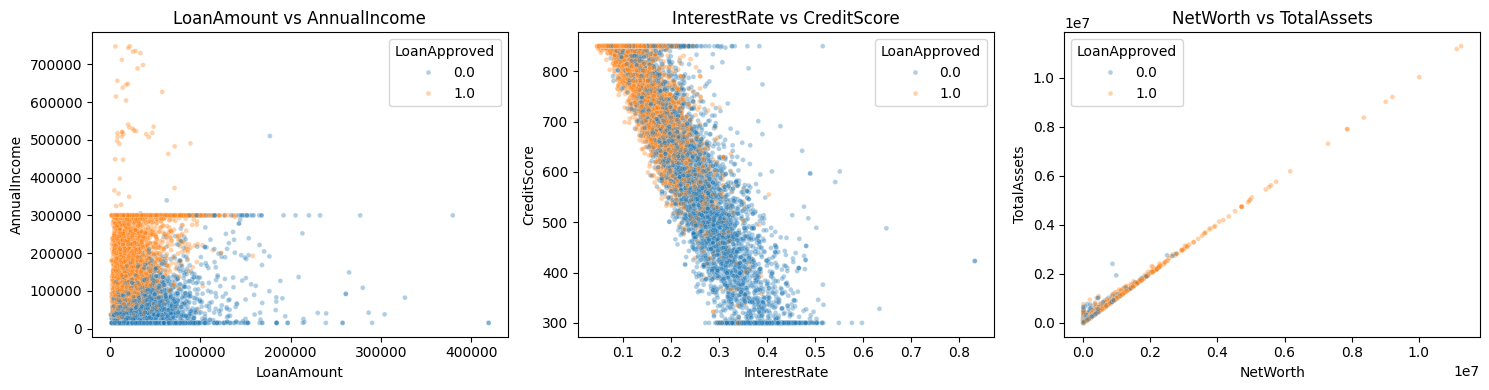

In [9]:
pairs = [
    ("LoanAmount", "AnnualIncome"),
    ("InterestRate", "CreditScore"),
    ("NetWorth", "TotalAssets"),
]
fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4))
for ax, (a, b) in zip(axes, pairs):
    sns.scatterplot(x=a, y=b, hue="LoanApproved", data=df, s=12, alpha=0.35, ax=ax)
    ax.set_title(f"{a} vs {b}")
plt.tight_layout()
plt.show()

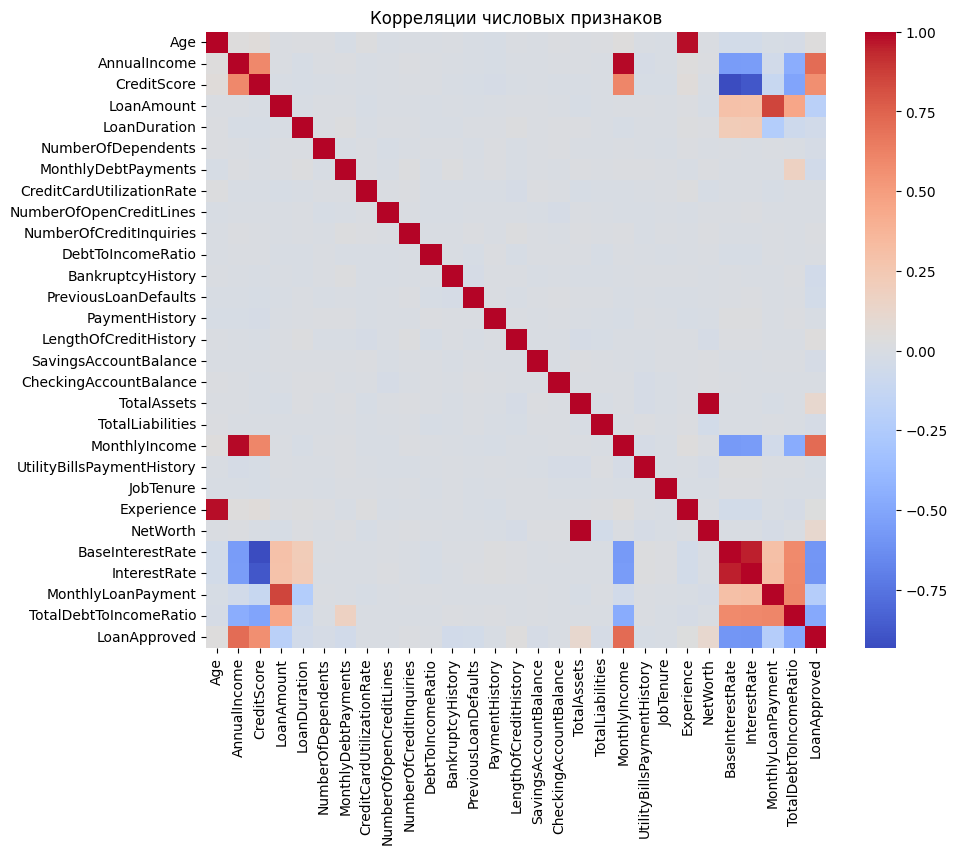

In [10]:
num = df.select_dtypes("number").replace([np.inf, -np.inf], np.nan)
num_f = num.apply(lambda s: s.fillna(s.median()))
corr = num_f.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Корреляции числовых признаков")
plt.show()

**Выводы EDA:** кредитный скор и долговая нагрузка сильнее всего разделяют классы, при этом доля положительных заявок ниже. Пропуски минимальны и закрываем медианой по числовым признакам. Категориальные признаки будем кодировать one-hot, числовые — масштабировать.

In [11]:
print(df["LoanApproved"].value_counts(normalize=True))
print("Положительных заявок:", df["LoanApproved"].mean())

LoanApproved
1.0    0.511776
0.0    0.488224
Name: proportion, dtype: float64
Положительных заявок: 0.5117764851721178


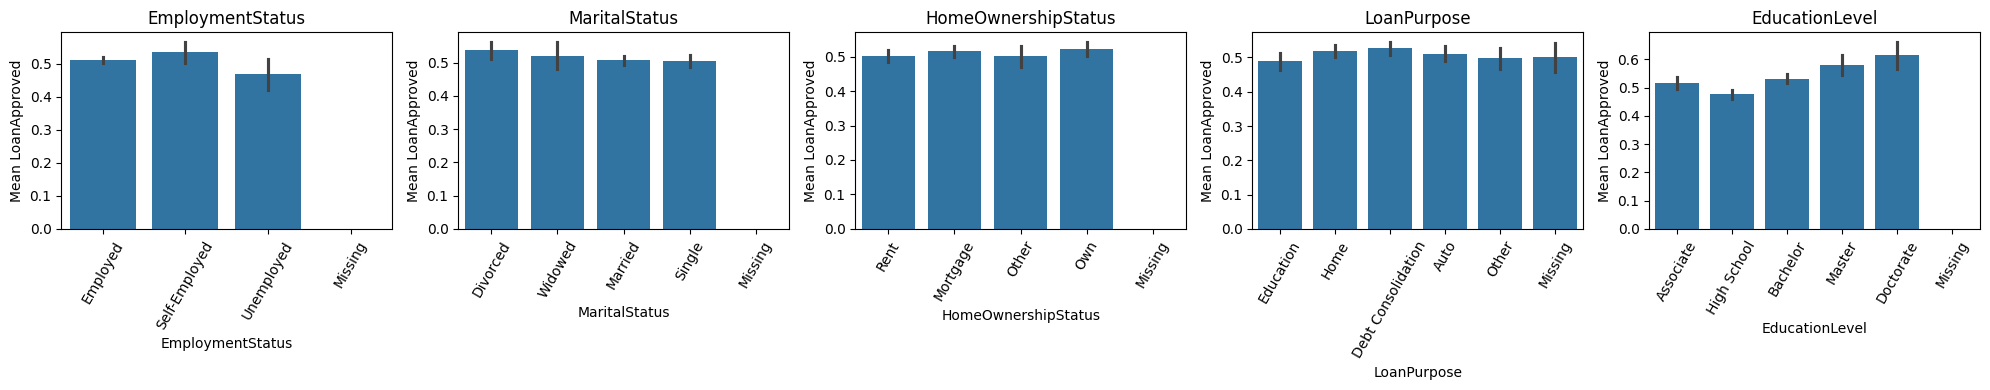

In [12]:
cat_cols = [
    "EmploymentStatus",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose",
    "EducationLevel",
]
fig, axes = plt.subplots(1, len(cat_cols), figsize=(4 * len(cat_cols), 4))
for ax, col in zip(axes, cat_cols):
    s = df[col].fillna("Missing")
    sns.barplot(x=s, y=df["LoanApproved"].astype(float), estimator=np.mean, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=60)
    ax.set_ylabel("Mean LoanApproved")
plt.tight_layout()
plt.show()

In [13]:
def norm(s):
    return (s - s.min()) / (s.max() - s.min())


def make_features(df_in):
    df = df_in.copy()

    # Даты
    df["ApplicationDate"] = pd.to_datetime(df["ApplicationDate"])
    min_date = pd.Timestamp("1970-01-01")
    df["AppYear"] = df["ApplicationDate"].dt.year
    df["AppMonth"] = df["ApplicationDate"].dt.month
    df["AppDays"] = (df["ApplicationDate"] - min_date).dt.days

    fill_cols = ["AnnualIncome", "TotalAssets", "TotalLiabilities", "NetWorth", "LoanDuration"]
    for c in fill_cols:
        if c in df.columns:
            df[c] = df[c].fillna(df[c].median())

    # Отношения
    df["Income_per_person"] = df["AnnualIncome"] / (df["NumberOfDependents"] + 1)
    df["Liabilities_to_Income"] = df["TotalLiabilities"] / (df["AnnualIncome"] + 10)
    df["Assets_to_Income"] = df["TotalAssets"] / (df["AnnualIncome"] + 10)
    df["Savings_to_Income"] = df["SavingsAccountBalance"] / (df["AnnualIncome"] + 10)

    for col in [
        "AnnualIncome",
        "LoanAmount",
        "TotalAssets",
        "TotalLiabilities",
        "NetWorth",
    ]:
        if col in df.columns:
            min_val = df[col].min()
            shift = abs(min_val) + 1.0 if min_val < 0 else 1.0
            df[f"log_{col}"] = np.log(df[col] + shift)

    # Взаимодействия
    df["Interest_Spread"] = df["InterestRate"] - df["BaseInterestRate"]
    df["CreditScore_sq"] = df["CreditScore"] ** 2

    df["Total_Payment_to_Income"] = (
        df["MonthlyDebtPayments"] + df["MonthlyLoanPayment"]
    ) / (df["MonthlyIncome"] + 10)
    df["Asset_Coverage"] = df["TotalAssets"] / (df["TotalLiabilities"] + 10)
    df["Negative_NetWorth"] = (df["NetWorth"] < 0).astype(int)
    df['Age_Bin'] = pd.qcut(df['Age'], q=5, labels=False, duplicates='drop')
    df['Income_Bin'] = pd.qcut(df['AnnualIncome'], q=5, labels=False, duplicates='drop')

    df['Dist_to_Bad'] = np.sqrt(
        norm(df['CreditScore']) ** 2 +
        norm(df['AnnualIncome']) ** 2 +
        (1 - norm(df['DebtToIncomeRatio'])) ** 2
    )

    df['Dist_to_Good'] = np.sqrt(
        (1 - norm(df['CreditScore'])) ** 2 +
        (1 - norm(df['AnnualIncome'])) ** 2 +
        norm(df['DebtToIncomeRatio']) ** 2
    )

    try:
        df['CreditScore_Bin'] = pd.qcut(df['CreditScore'], q=10, labels=False, duplicates='drop')
    except:
        pass

    df['LoanAmount_Bin'] = pd.qcut(df['LoanAmount'], q=10, labels=False, duplicates='drop')
    df['DTI_Bin'] = pd.qcut(df['DebtToIncomeRatio'], q=10, labels=False, duplicates='drop')

    if 'LoanDuration' in df.columns:
        df['Duration_Cat'] = df['LoanDuration'].round().astype(int).astype(str)

    try:
        df['NetWorth_Bin'] = pd.qcut(df['NetWorth'], q=5, labels=False, duplicates='drop')
    except:
        pass

    if 'ApplicationDate' in df.columns:
        df = df.drop(columns=['ApplicationDate'])

    return df

In [14]:
df_feat = make_features(df.drop(columns=["LoanApproved"]))
test_feat = make_features(test)

y = df["LoanApproved"].fillna(df["LoanApproved"].mode()[0]).astype(int).values

cat_cols = df_feat.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in df_feat.columns if c not in cat_cols]

numeric_tf = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_tf = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    [
        ("num", numeric_tf, num_cols),
        ("cat", categorical_tf, cat_cols),
    ]
)

X_all = preprocess.fit_transform(df_feat)
X_test_all = preprocess.transform(test_feat)

if sp.issparse(X_all):
    X_all = X_all.tocsr()
    X_test_all = X_test_all.tocsr()

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y, test_size=0.2, stratify=y, random_state=42
)


def to_dense(mat):
    return mat.toarray() if sp.issparse(mat) else mat


X_train_dense = to_dense(X_train)
X_val_dense = to_dense(X_val)
X_all_dense = to_dense(X_all)
X_test_dense = to_dense(X_test_all)

In [15]:

X_scaled_train = X_train_dense
X_scaled_test = X_test_dense
print(f"Всего признаков: {X_scaled_train.shape[1]}")

Всего признаков: 84


In [16]:
class MyGradientBoostingClassifier:
    def __init__(
        self,
        n_estimators=60,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
    ):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = []
        self.init_log_odds = 0.0

    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X, y):
        y = np.asarray(y)
        p = np.clip(y.mean(), 1e-5, 1 - 1e-5)
        self.init_log_odds = np.log(p / (1 - p))
        f = np.full_like(y, self.init_log_odds, dtype=float)
        self.trees = []

        for m in range(self.n_estimators):
            p_hat = self._sigmoid(f)
            residual = y - p_hat 
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth, random_state=self.random_state + m
            )
            tree.fit(X, residual)
            self.trees.append(tree)
            f += self.learning_rate * tree.predict(X)
        return self

    def predict_proba(self, X):
        f = np.full(X.shape[0], self.init_log_odds, dtype=float)
        for tree in self.trees:
            f += self.learning_rate * tree.predict(X)
        p_hat = self._sigmoid(f)
        return np.vstack([1 - p_hat, p_hat]).T

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


метрики

In [58]:
def my_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


def my_precision(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp + 1e-12)


def my_recall(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn + 1e-12)


def my_f1(y_true, y_pred):
    p = my_precision(y_true, y_pred)
    r = my_recall(y_true, y_pred)
    return 2 * p * r / (p + r + 1e-12)


def my_roc_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    order = np.argsort(-y_score)
    y_true = y_true[order]
    y_score = y_score[order]
    tps = np.cumsum(y_true)
    fps = np.cumsum(1 - y_true)
    tpr = tps / (tps[-1] + 1e-12)
    fpr = fps / (fps[-1] + 1e-12)
    return np.trapz(tpr, fpr)


def my_pr_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    order = np.argsort(-y_score)
    y_true = y_true[order]
    tp = np.cumsum(y_true)
    fp = np.cumsum(1 - y_true)
    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp[-1] + 1e-12)
    return np.trapz(precision, recall)


def evaluate_metrics(y_true, y_pred, y_proba):
    return {
        "acc": my_accuracy(y_true, y_pred),
        "precision": my_precision(y_true, y_pred),
        "recall": my_recall(y_true, y_pred),
        "f1": my_f1(y_true, y_pred),
        "roc_auc": my_roc_auc(y_true, y_proba),
        "pr_auc": my_pr_auc(y_true, y_proba),
    }


def compare_with_sklearn(y_true, y_pred, y_proba):
    return {
        "acc_sk": accuracy_score(y_true, y_pred),
        "precision_sk": precision_score(y_true, y_pred),
        "recall_sk": recall_score(y_true, y_pred),
        "f1_sk": f1_score(y_true, y_pred),
        "roc_auc_sk": roc_auc_score(y_true, y_proba),
        "pr_auc_sk": average_precision_score(y_true, y_proba),
    }


In [59]:
class MyBaggingClassifier:
    def __init__(
        self,
        base_estimator=None,
        n_estimators=20,
        max_samples=0.8,
        random_state=42,
    ):
        self.base_estimator = base_estimator or DecisionTreeClassifier(max_depth=None)
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.random_state = random_state
        self.models = []

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        n_samples = int(self.max_samples * len(X))
        self.models = []
        for i in range(self.n_estimators):
            idx = rng.choice(len(X), size=n_samples, replace=True)
            model = clone(self.base_estimator)
            model.fit(X[idx], y[idx])
            self.models.append(model)
        return self

    def predict_proba(self, X):
        if not self.models:
            raise RuntimeError("Model is not fitted")
        probs = np.stack([m.predict_proba(X)[:, 1] for m in self.models], axis=1)
        mean_prob = probs.mean(axis=1)
        return np.vstack([1 - mean_prob, mean_prob]).T

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)


In [61]:
# Бэггинг: своя реализация vs sklearn
base_tree = DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, random_state=42)

my_bag = MyBaggingClassifier(
    base_estimator=base_tree, n_estimators=30, max_samples=0.9, random_state=42
)
my_bag.fit(X_train_dense, y_train)
proba_my = my_bag.predict_proba(X_val_dense)[:, 1]
pred_my = (proba_my >= 0.5).astype(int)

sk_bag = BaggingClassifier(
    estimator=base_tree,
    n_estimators=30,
    max_samples=0.9,
    random_state=42,
    n_jobs=-1,
)
sk_bag.fit(X_train, y_train)
proba_sk = sk_bag.predict_proba(X_val)[:, 1]
pred_sk = sk_bag.predict(X_val)

print("=== MyBagging ===")
print(evaluate_metrics(y_val, pred_my, proba_my))
print(compare_with_sklearn(y_val, pred_my, proba_my))

print("\n=== sklearn BaggingClassifier ===")
print(evaluate_metrics(y_val, pred_sk, proba_sk))
print(compare_with_sklearn(y_val, pred_sk, proba_sk))

=== MyBagging ===
{'acc': 0.9224137931034483, 'precision': 0.9200666111573682, 'recall': 0.936440677966101, 'f1': 0.9281814363707719, 'roc_auc': 0.9795410156249985, 'pr_auc': 0.9823377204622414}
{'acc_sk': 0.9224137931034483, 'precision_sk': 0.9200666111573689, 'recall_sk': 0.9364406779661016, 'f1_sk': 0.9281814363712726, 'roc_auc_sk': 0.9795372914459745, 'pr_auc_sk': 0.9832028143172915}

=== sklearn BaggingClassifier ===
{'acc': 0.9246823956442831, 'precision': 0.9232053422370611, 'recall': 0.9372881355932197, 'f1': 0.9301934398649324, 'roc_auc': 0.9790957693326254, 'pr_auc': 0.9818011238450632}
{'acc_sk': 0.9246823956442831, 'precision_sk': 0.9232053422370617, 'recall_sk': 0.9372881355932203, 'f1_sk': 0.9301934398654331, 'roc_auc_sk': 0.979095769332627, 'pr_auc_sk': 0.9826562063438493}


In [62]:
# Градиентный бустинг: своя реализация vs sklearn
my_gb = MyGradientBoostingClassifier(n_estimators=120, learning_rate=0.1, max_depth=3)
my_gb.fit(X_train_dense, y_train)
proba_my_gb = my_gb.predict_proba(X_val_dense)[:, 1]
pred_my_gb = (proba_my_gb >= 0.5).astype(int)

sk_gb = GradientBoostingClassifier(random_state=42)
sk_gb.fit(X_train, y_train)
proba_sk_gb = sk_gb.predict_proba(X_val)[:, 1]
pred_sk_gb = sk_gb.predict(X_val)

print("=== MyGradientBoosting ===")
print(evaluate_metrics(y_val, pred_my_gb, proba_my_gb))
print(compare_with_sklearn(y_val, pred_my_gb, proba_my_gb))

print("\n=== sklearn GradientBoostingClassifier ===")
print(evaluate_metrics(y_val, pred_sk_gb, proba_sk_gb))
print(compare_with_sklearn(y_val, pred_sk_gb, proba_sk_gb))


=== MyGradientBoosting ===
{'acc': 0.9233212341197822, 'precision': 0.918806959403479, 'recall': 0.9398305084745755, 'f1': 0.9291998324251383, 'roc_auc': 0.9774827860169476, 'pr_auc': 0.9802240666899509}
{'acc_sk': 0.9233212341197822, 'precision_sk': 0.9188069594034797, 'recall_sk': 0.9398305084745763, 'f1_sk': 0.9291998324256389, 'roc_auc_sk': 0.977412854210805, 'pr_auc_sk': 0.9810297052642822}

=== sklearn GradientBoostingClassifier ===
{'acc': 0.9314882032667876, 'precision': 0.9291075896580476, 'recall': 0.9440677966101688, 'f1': 0.9365279529208949, 'roc_auc': 0.9835515426377103, 'pr_auc': 0.9856416902340825}
{'acc_sk': 0.9314882032667876, 'precision_sk': 0.9291075896580484, 'recall_sk': 0.9440677966101695, 'f1_sk': 0.9365279529213956, 'roc_auc_sk': 0.9835515426377117, 'pr_auc_sk': 0.9865044611570855}


In [63]:
models = []

try:
    from lightgbm import LGBMClassifier

    models.append(
        (
            "LightGBM",
            LGBMClassifier(
                n_estimators=400,
                max_depth=-1,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=42,
            ),
        )
    )
except ImportError:
    print("LightGBM не установлен")

try:
    from xgboost import XGBClassifier

    models.append(
        (
            "XGBoost",
            XGBClassifier(
                n_estimators=400,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="binary:logistic",
                eval_metric="auc",
                random_state=42,
                n_jobs=-1,
            ),
        )
    )
except ImportError:
    print("XGBoost не установлен")

try:
    from catboost import CatBoostClassifier

    models.append(
        (
            "CatBoost",
            CatBoostClassifier(
                iterations=500,
                depth=6,
                learning_rate=0.05,
                eval_metric="AUC",
                verbose=False,
                random_seed=42,
            ),
        )
    )
except ImportError:
    print("CatBoost не установлен")

results = []
for name, model in models:
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_val)[:, 1]
    pred = (proba >= 0.5).astype(int)
    res = evaluate_metrics(y_val, pred, proba)
    res["model"] = name
    results.append(res)
    print(f"\n=== {name} ===")
    print(res)

if results:
    results_df = pd.DataFrame(results).sort_values(by="roc_auc", ascending=False)
    display(results_df)
else:
    print("Нет установленных внешних бустинг-библиотек")

[LightGBM] [Info] Number of positive: 4717, number of negative: 4096
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001539 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8769
[LightGBM] [Info] Number of data points in the train set: 8813, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.535232 -> initscore=0.141162
[LightGBM] [Info] Start training from score 0.141162


c:\Users\ivglu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== LightGBM ===
{'acc': 0.9355716878402904, 'precision': 0.9376053962900499, 'recall': 0.9423728813559314, 'f1': 0.939983093828747, 'roc_auc': 0.9851835606461847, 'pr_auc': 0.9869998198101014, 'model': 'LightGBM'}

=== XGBoost ===
{'acc': 0.9323956442831216, 'precision': 0.9342881213142369, 'recall': 0.9398305084745755, 'f1': 0.9370511195601245, 'roc_auc': 0.9853300450211848, 'pr_auc': 0.9872649801789322, 'model': 'XGBoost'}

=== XGBoost ===
{'acc': 0.9323956442831216, 'precision': 0.9342881213142369, 'recall': 0.9398305084745755, 'f1': 0.9370511195601245, 'roc_auc': 0.9853300450211848, 'pr_auc': 0.9872649801789322, 'model': 'XGBoost'}

=== CatBoost ===
{'acc': 0.9364791288566243, 'precision': 0.941426146010186, 'recall': 0.9398305084745755, 'f1': 0.9406276505508139, 'roc_auc': 0.9856031514830491, 'pr_auc': 0.9872676940021526, 'model': 'CatBoost'}

=== CatBoost ===
{'acc': 0.9364791288566243, 'precision': 0.941426146010186, 'recall': 0.9398305084745755, 'f1': 0.9406276505508139, 'roc

,acc,precision,recall,f1,roc_auc,pr_auc,model
2,0.936479,0.941426,0.939831,0.940628,0.985603,0.987268,CatBoost
1,0.932396,0.934288,0.939831,0.937051,0.985330,0.987265,XGBoost
0,0.935572,0.937605,0.942373,0.939983,0.985184,0.987000,LightGBM


In [64]:
try:
    import optuna
    from xgboost import XGBClassifier

    def objective(trial):
        max_depth = trial.suggest_int("max_depth", 3, 8)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
        n_estimators = trial.suggest_int("n_estimators", 150, 500)
        subsample = trial.suggest_float("subsample", 0.6, 1.0)
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)

        model = XGBClassifier(
            max_depth=max_depth,
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            objective="binary:logistic",
            eval_metric="auc",
            random_state=42,
            n_jobs=-1,
        )
        model.fit(X_train, y_train, verbose=False)
        proba = model.predict_proba(X_val)[:, 1]
        return roc_auc_score(y_val, proba)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=25, timeout=600)
    best_params = study.best_params
    print("Лучшие параметры XGBoost:", best_params)

except ImportError:
    print("Optuna/XGBoost не установлены, пропускаем подбор гиперпараметров")
    best_params = None


[I 2025-12-09 16:03:58,637] A new study created in memory with name: no-name-b300f3fb-ad36-4bf5-92fd-173e988ae040
[I 2025-12-09 16:03:59,067] Trial 0 finished with value: 0.9849774894067796 and parameters: {'max_depth': 4, 'learning_rate': 0.02370601222654304, 'n_estimators': 495, 'subsample': 0.6797577106296723, 'colsample_bytree': 0.7536376497869366}. Best is trial 0 with value: 0.9849774894067796.
[I 2025-12-09 16:03:59,067] Trial 0 finished with value: 0.9849774894067796 and parameters: {'max_depth': 4, 'learning_rate': 0.02370601222654304, 'n_estimators': 495, 'subsample': 0.6797577106296723, 'colsample_bytree': 0.7536376497869366}. Best is trial 0 with value: 0.9849774894067796.
[I 2025-12-09 16:03:59,406] Trial 1 finished with value: 0.9853159759004237 and parameters: {'max_depth': 6, 'learning_rate': 0.1200816955265248, 'n_estimators': 248, 'subsample': 0.7656877175376225, 'colsample_bytree': 0.6634846732811172}. Best is trial 1 with value: 0.9853159759004237.
[I 2025-12-09 16:

Лучшие параметры XGBoost: {'max_depth': 4, 'learning_rate': 0.10606831893167624, 'n_estimators': 331, 'subsample': 0.6660415125360087, 'colsample_bytree': 0.9577560951164935}


In [ ]:

final_model = None

best_external = None
if "results" in locals() and results:
    results_df = pd.DataFrame(results).sort_values(by="roc_auc", ascending=False)
    best_external = results_df.iloc[0]["model"]

try:
    from xgboost import XGBClassifier 
    has_xgb = True
except ImportError:
    has_xgb = False

if "best_params" in locals() and best_params and has_xgb:
    final_model = XGBClassifier(
        **best_params,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1,
    )
elif best_external:
    final_model = dict(models)[best_external]
else:
    final_model = MyGradientBoostingClassifier(
        n_estimators=200, learning_rate=0.08, max_depth=3, random_state=42
    )

if isinstance(final_model, MyGradientBoostingClassifier):
    final_model.fit(X_all_dense, y)
    final_proba = final_model.predict_proba(X_test_dense)[:, 1]
else:
    final_model.fit(X_all, y)
    final_proba = final_model.predict_proba(X_test_all)[:, 1]

submission = pd.DataFrame({"ID": test["ID"], "LoanApproved": final_proba})
submission.to_csv("submission.csv", index=False)
submission.head()

,ID,LoanApproved
0,0,0.999126
1,1,0.003297
2,2,0.999768
3,3,0.999324
4,4,0.999482
